
Neural Transfer Using PyTorch
=============================


#### 作者: [Alexis Jacq](https://alexis-jacq.github.io)
#### 原始程式碼：[NEURAL TRANSFER USING PYTORCH](https://pytorch.org/tutorials/advanced/neural_style_tutorial.html#neural-transfer-using-pytorch)

## 載入套件

In [1]:
from __future__ import print_function

from typing import List, Optional, Tuple, Union, cast

import matplotlib.pyplot as plt
import torch
from torch import nn, optim
from torch.nn import functional as F
from torchvision import models, transforms
from PIL import Image

## 判斷是否使用 GPU

In [2]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
device

'mps'

## 定義讀取圖檔、顯示/轉換圖像的函數

In [3]:
# 如果無 GPU 使用較小尺寸的圖像
imsize = 512 if torch.cuda.is_available() or torch.mps.is_available() else 128

# 轉換
loader = transforms.Compose(
    [
        transforms.Resize((imsize, imsize)),  # 統一圖像尺寸
        transforms.ToTensor(),
    ]
)


# 讀取圖檔，轉為張量
def image_loader(image_name: str) -> torch.Tensor:
    image = Image.open(image_name)
    image = cast(torch.Tensor, loader(image)).unsqueeze(0)  # 增加一維
    return image.to(device, torch.float)


unloader = transforms.ToPILImage()  # 張量轉為 PIL Image 格式


# 顯示圖像
def imshow(tensor: torch.Tensor, title: Optional[str] = None) -> None:
    image = tensor.cpu().clone()  # 複製張量
    image = image.squeeze(0)  # 減少一維
    image = unloader(image)
    plt.axis('off')
    plt.imshow(image)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # 顯示多張圖須停頓，等畫面更新

## 載入內容圖檔、風格圖檔

torch.Size([1, 3, 512, 512]) torch.Size([1, 3, 512, 512])


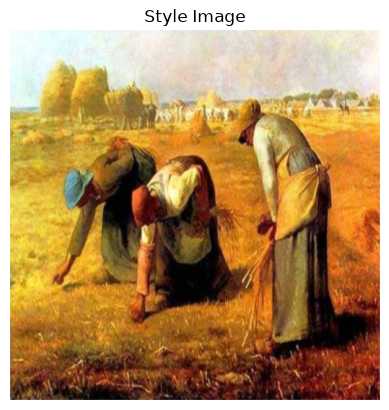

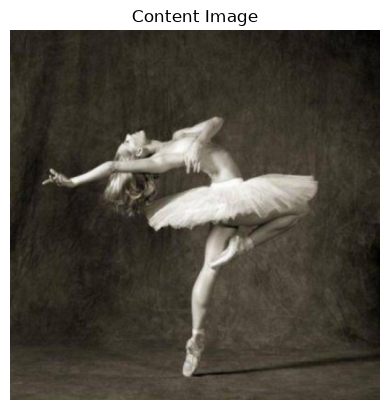

In [4]:
style_img = image_loader("StyleTransfer/des_glaneuses.jpg")
content_img = image_loader("StyleTransfer/dancing.jpg")
print(style_img.shape, content_img.shape)
imshow(style_img, title='Style Image')
imshow(content_img, title='Content Image')

## 定義內容損失函數

In [5]:
class ContentLoss(nn.Module):
    def __init__(
        self,
        target: torch.Tensor,
    ):
        super(ContentLoss, self).__init__()
        # we 'detach' the target content from the tree used
        # to dynamically compute the gradient: this is a stated value,
        # not a variable. Otherwise the forward method of the criterion
        # will throw an error.
        self.target = target.detach()

    def forward(self, input: torch.Tensor) -> torch.Tensor:
        self.loss = F.mse_loss(input, self.target)
        return input

## 定義 gram matrix

In [6]:
def gram_matrix(input: torch.Tensor) -> torch.Tensor:
    # a: 批量(=1)
    # b: feature map 數量
    # (c,d): feature maps維度大小 (N=c*d)
    a, b, c, d = input.size()

    features = input.view(a * b, c * d)  # resise F_XL into \hat F_XL

    G = torch.mm(features, features.t())  # compute the gram product

    return G.div(a * b * c * d)

## 定義風格損失函數

In [7]:
class StyleLoss(nn.Module):
    def __init__(self, target_feature: torch.Tensor) -> None:
        super(StyleLoss, self).__init__()
        self.target = gram_matrix(target_feature).detach()

    def forward(self, input: torch.Tensor) -> torch.Tensor:
        G = gram_matrix(input)
        self.loss = F.mse_loss(G, self.target)
        return input

## 載入VGG 19模型

In [8]:
cnn = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features.to(device).eval()

## 標準化

In [9]:
cnn_normalization_mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
cnn_normalization_std = torch.tensor([0.229, 0.224, 0.225]).to(device)


# 標準化函數
class Normalization(nn.Module):
    def __init__(self, mean: torch.Tensor, std: torch.Tensor) -> None:
        super(Normalization, self).__init__()
        # .view the mean and std to make them [C x 1 x 1] so that they can
        # directly work with image Tensor of shape [B x C x H x W].
        # B is batch size. C is number of channels. H is height and W is width.
        self.mean = torch.tensor(mean).view(-1, 1, 1)
        self.std = torch.tensor(std).view(-1, 1, 1)

    def forward(self, img: torch.Tensor) -> torch.Tensor:
        # normalize img
        return (img - self.mean) / self.std

## 定義內容圖和風格圖輸出的卷積層名稱

In [10]:
# 在下列卷積層後計算損失
content_layers_default = ['conv_4']
style_layers_default = ['conv_1', 'conv_2', 'conv_3', 'conv_4', 'conv_5']

## 修改模型：只取VGG19的卷積層、池化層、ReLU Activation Function及Batch Normalization層。

In [11]:
# 定義卷積層後的損失計算函數
def get_style_model_and_losses(
    cnn: nn.Module,
    normalization_mean: torch.Tensor,
    normalization_std: torch.Tensor,
    style_img: torch.Tensor,
    content_img: torch.Tensor,
    content_layers: List[str] = content_layers_default,
    style_layers: List[str] = style_layers_default,
) -> Tuple[nn.Sequential, List[StyleLoss], List[ContentLoss]]:
    # 標準化
    normalization = Normalization(normalization_mean, normalization_std).to(device)

    # 變數初始化
    content_losses = []
    style_losses = []

    # 模型先加入標準化的神經層
    model = nn.Sequential(normalization)

    i = 0  # increment every time we see a conv
    for layer in cnn.children():
        if isinstance(layer, nn.Conv2d):
            i += 1
            name = f'conv_{i}'
        elif isinstance(layer, nn.ReLU):
            name = f'relu_{i}'
            # inplace=True 效果不佳
            layer = nn.ReLU(inplace=False)
        elif isinstance(layer, nn.MaxPool2d):
            name = f'pool_{i}'
        elif isinstance(layer, nn.BatchNorm2d):
            name = f'bn_{i}'
        else:
            raise RuntimeError(f'Unrecognized layer: {layer.__class__.__name__}')

        model.add_module(name, layer)

        if name in content_layers:
            # add content loss:
            target = model(content_img).detach()
            content_loss = ContentLoss(target)
            model.add_module(f"content_loss_{i}", content_loss)
            content_losses.append(content_loss)

        if name in style_layers:
            # add style loss:
            target_feature = model(style_img).detach()
            style_loss = StyleLoss(target_feature)
            model.add_module(f"style_loss_{i}", style_loss)
            style_losses.append(style_loss)

    # 不加入卷積層後的辨識層
    for i in range(len(model) - 1, -1, -1):
        if isinstance(model[i], ContentLoss) or isinstance(model[i], StyleLoss):
            break

    model = cast(nn.Sequential, model[: (i + 1)])

    return model, style_losses, content_losses

## 以梯度下降法訓練模型

In [ ]:
def get_input_optimizer(input_img: torch.Tensor) -> optim.LBFGS:
    # 設定 input image 要優化
    optimizer = optim.LBFGS([input_img])
    return optimizer


def run_style_transfer(
    cnn: nn.Module,
    normalization_mean: torch.Tensor,
    normalization_std: torch.Tensor,
    content_img: torch.Tensor,
    style_img: torch.Tensor,
    input_img: torch.Tensor,
    num_steps: int = 300,
    style_weight: Union[int, float] = 1000000,
    content_weight: Union[int, float] = 1,
) -> torch.Tensor:
    print('Building the style transfer model..')
    model, style_losses, content_losses = get_style_model_and_losses(
        cnn, normalization_mean, normalization_std, style_img, content_img
    )

    # 優化 input image, 而不是求權重
    input_img.requires_grad_(True)
    model.requires_grad_(False)
    optimizer = get_input_optimizer(input_img)

    print('優化 ..')
    run = [0]
    while run[0] <= num_steps:

        def closure():
            # 限定像素值介於 [0, 1]
            with torch.no_grad():
                input_img.clamp_(0, 1)

            # 計算損失
            optimizer.zero_grad()
            model(input_img)
            style_score = 0
            content_score = 0

            for sl in style_losses:
                style_score += sl.loss
            for cl in content_losses:
                content_score += cl.loss

            style_score *= style_weight
            content_score *= content_weight

            loss = style_score + content_score
            loss.backward()

            # 顯示執行訊息
            run[0] += 1
            if run[0] % 50 == 0:
                print(f"run {run}:")
                print(f'Style Loss : {style_score.item():4f} Content Loss: {content_score.item():4f}')
                print()

            return style_score + content_score

        optimizer.step(closure)

    with torch.no_grad():
        input_img.clamp_(0, 1)

    return input_img

Building the style transfer model..
優化 ..


/var/folders/12/kxxl4khx6b9fjm12yv7z63y40000gn/T/ipykernel_21775/3367509225.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.mean = torch.tensor(mean).view(-1, 1, 1)
/var/folders/12/kxxl4khx6b9fjm12yv7z63y40000gn/T/ipykernel_21775/3367509225.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.std = torch.tensor(std).view(-1, 1, 1)


run [50]:
Style Loss : 198.939926 Content Loss: 9.918310

run [100]:
Style Loss : 116.489220 Content Loss: 9.989121

run [150]:
Style Loss : 69.957947 Content Loss: 11.159175

run [200]:
Style Loss : 45.142071 Content Loss: 11.161129

run [250]:
Style Loss : 36.907959 Content Loss: 10.702433

run [300]:
Style Loss : 28.121252 Content Loss: 10.838717



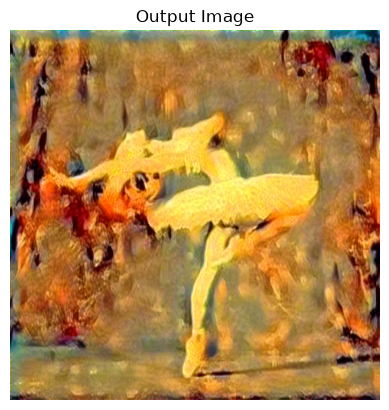

In [13]:
input_img = content_img.clone()
output = run_style_transfer(cnn, cnn_normalization_mean, cnn_normalization_std, content_img, style_img, input_img)

plt.ion()

plt.figure()
imshow(output, title='Output Image')

# sphinx_gallery_thumbnail_number = 4
plt.ioff()
plt.show()

## 測試另一組圖檔

torch.Size([1, 3, 512, 512]) torch.Size([1, 3, 512, 512])


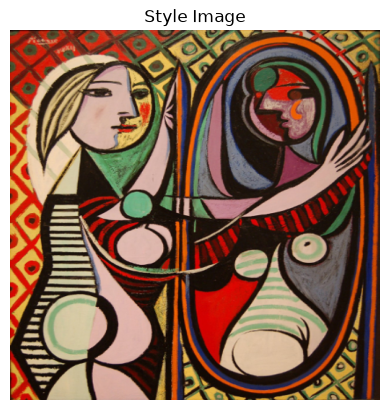

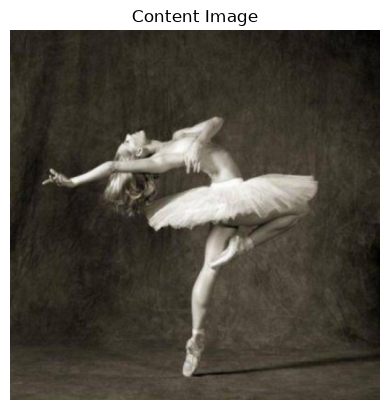

In [14]:
style_img = image_loader("StyleTransfer/mirror.jpg")
content_img = image_loader("StyleTransfer/dancing.jpg")
print(style_img.shape, content_img.shape)
imshow(style_img, title='Style Image')
imshow(content_img, title='Content Image')

Building the style transfer model..
優化 ..


/var/folders/12/kxxl4khx6b9fjm12yv7z63y40000gn/T/ipykernel_21775/3367509225.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.mean = torch.tensor(mean).view(-1, 1, 1)
/var/folders/12/kxxl4khx6b9fjm12yv7z63y40000gn/T/ipykernel_21775/3367509225.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.std = torch.tensor(std).view(-1, 1, 1)


run [50]:
Style Loss : 871.783691 Content Loss: 43.536545

run [100]:
Style Loss : 195.129654 Content Loss: 43.699993

run [150]:
Style Loss : 67.236023 Content Loss: 43.323181

run [200]:
Style Loss : 31.661638 Content Loss: 42.681339

run [250]:
Style Loss : 18.474161 Content Loss: 42.035748

run [300]:
Style Loss : 12.090902 Content Loss: 41.041451



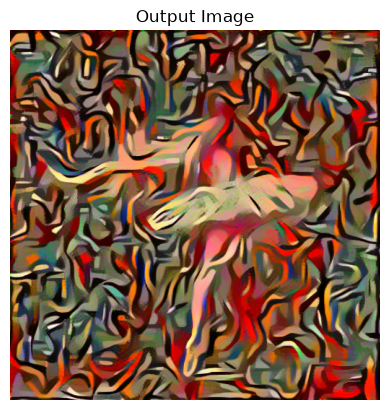

In [15]:
input_img = content_img.clone()
output = run_style_transfer(cnn, cnn_normalization_mean, cnn_normalization_std, content_img, style_img, input_img)

plt.ion()

plt.figure()
imshow(output, title='Output Image')

# sphinx_gallery_thumbnail_number = 4
plt.ioff()
plt.show()